# Exercício Exploratório Before.IT — Parte 4

Nesta seção final da exploração, vamos analisar os resultados da alteração feita ao introduzir a transferência de renda da população trabalhadora para os donos das empresas no modelo como proxy de um mercado de apostas. 

Para fazer isto, vamos:
1. Entender como foi feita a transferência de renda.
2. Aprofundar a análise do impacto das transferências sobre o PIB. 
3. Procurar explicar os mecanismos deste impacto.

## Transferências do mercado de apostas

O mercado de apostas foi introduzido como um mecanismo estilizado de transferência de renda entre famílias. Nesta versão, não existem casas de apostas, produção de serviços de apostas, probabilidades de vitória ou tributação específica, o mecanismo representa uma transferência recorrente de trabalhadores para proprietários de empresas. A implementação detalhada do mecanismo aparece na **Parte 2, Seção 2.37: Transferências do mercado de apostas**.

### Participantes e parâmetros

Sejam:

- $g \in [0,1]$ a parcela da renda destinada às apostas, armazenada em `gambling_income_share`;
- $G_A$ o conjunto fixo de trabalhadores ativos selecionados;
- $G_N$ o conjunto fixo de trabalhadores inativos selecionados;
- $R$ o conjunto de proprietários de empresas que recebem os recursos;
- $Y^{A,0}_{h,t}$ e $Y^{N,0}_{h,t}$ as rendas dos trabalhadores antes das apostas;
- $Y^{O,0}_{i,t}$ a renda dos proprietários antes dos recebimentos.

Na configuração inicial, aproximadamente 10% dos trabalhadores são selecionados como apostadores e 10% dos proprietários como destinatários. Os mesmos agentes permanecem nessas funções durante toda a simulação. No cenário com apostas, utiliza-se $g=0{,}02$; no cenário de referência, $g=0$.

Abaixo temos um diagrama que ilustra o impacto da alteração na simulação: 

```{mermaid}
%%| fig-width: 5.0
flowchart TB
    subgraph MT["1. Mercado de trabalho"]
        direction LR
        A["Demanda de trabalho<br/>das empresas"]
        B["Contratações<br/>e demissões"]
        C["Emprego, salários<br/>e produção"]

        A --> B --> C
    end

    subgraph OP["2. Formação dos orçamentos"]
        direction LR
        D["Rendas esperadas<br/>das famílias"]
        E["Transferência esperada<br/>das apostas"]
        F["Renda esperada<br/>após as apostas"]
        G["Consumo e investimento<br/>desejados"]

        D --> E --> F --> G
    end

    subgraph MB["3. Mercado de bens"]
        direction LR
        H["Pareamento entre compradores<br/>e fornecedores"]
        I["Compras e vendas<br/>realizadas"]

        H --> I
    end

    subgraph RS["4. Resultados e balanços"]
        direction LR
        J["Lucros e rendas<br/>realizados"]
        K["Transferência efetiva<br/>das apostas"]
        L["Depósitos e balanços<br/>atualizados"]

        J --> K --> L
    end

    MT --> OP --> MB --> RS
    RS -. "próximo período" .-> MT

    classDef trabalho fill:#e8f1fb,stroke:#3976a8,color:#172b3a;
    classDef apostas fill:#fff3d6,stroke:#c58a18,color:#3d2d0d;
    classDef bens fill:#e7f5eb,stroke:#3b8c55,color:#173622;
    classDef resultado fill:#f1ecf8,stroke:#79589f,color:#2f2040;

    class A,B,C trabalho;
    class E,F,K apostas;
    class G,H,I bens;
    class D,J,L resultado;
```

### Valor transferido pelos trabalhadores

Cada trabalhador selecionado transfere uma proporção fixa de sua renda disponível não negativa:

$$
B^A_{h,t}=\mathbf{1}(h\in G_A)\,g\max(0,Y^{A,0}_{h,t}),
$$

$$
B^N_{h,t}=\mathbf{1}(h\in G_N)\,g\max(0,Y^{N,0}_{h,t}).
$$

O operador $\max(0,Y)$ impede que agentes com renda negativa realizem apostas. Trabalhadores não selecionados transferem zero. O desconto sobre as rendas esperadas é apresentado na **Parte 2, Seção 2.18: Orçamento dos trabalhadores ativos** e na **Seção 2.19: Orçamento das pessoas inativas**.

O volume total de apostas no período é:

$$
B_t=\sum_h B^A_{h,t}+\sum_h B^N_{h,t}.
$$

Esse valor é armazenado pelo modelo em `gambling_volume`.

### Distribuição aos proprietários

O volume arrecadado é dividido igualmente entre os proprietários selecionados:

$$
R_{i,t}=
\begin{cases}
\dfrac{B_t}{|R|}, & i\in R,\\[6pt]
0, & i\notin R.
\end{cases}
$$

A inclusão dessas receitas no orçamento esperado dos beneficiários é detalhada na **Parte 2, Seção 2.20: Orçamento dos proprietários das empresas**. As rendas depois da transferência são:

$$
Y^A_{h,t}=Y^{A,0}_{h,t}-B^A_{h,t},
$$

$$
Y^N_{h,t}=Y^{N,0}_{h,t}-B^N_{h,t},
$$

$$
Y^O_{i,t}=Y^{O,0}_{i,t}+R_{i,t}.
$$

O proprietário do banco não participa do mecanismo, nem como apostador nem como destinatário. Seu orçamento permanece conforme a **Parte 2, Seção 2.21: Orçamento do proprietário do banco**.

### Conservação da renda

A transferência é de soma zero, pois todo o valor retirado dos trabalhadores é entregue aos proprietários:

$$
\sum_h B^A_{h,t}+\sum_h B^N_{h,t}=\sum_i R_{i,t}.
$$

Consequentemente, a renda agregada das famílias é preservada:

$$
\sum_h Y^A_{h,t}+\sum_h Y^N_{h,t}+\sum_i Y^O_{i,t}
=\sum_h Y^{A,0}_{h,t}+\sum_h Y^{N,0}_{h,t}+\sum_i Y^{O,0}_{i,t}.
$$

A demonstração operacional dessa conservação encontra-se na **Parte 2, Seção 2.37**. A transferência não é tributada, não representa produção e não é adicionada diretamente ao PIB.

### Incorporação no ciclo do modelo

O mecanismo aparece em dois momentos distintos:

1. **Formação dos orçamentos:** a transferência esperada é descontada da renda dos apostadores e adicionada à renda dos proprietários antes do cálculo das demandas desejadas, conforme as **Seções 2.18 a 2.20 da Parte 2**.

2. **Atualização contábil:** depois do cálculo das rendas realizadas nas **Seções 2.33 a 2.35 da Parte 2**, a transferência efetiva é executada pela rotina descrita na **Seção 2.37**, antes da atualização dos depósitos apresentada nas **Seções 2.38 a 2.40**.

A renda esperada após as apostas, $\widetilde{Y}^{e}_{h,t}$, determina as demandas desejadas:

$$
C^d_{h,t}=\frac{\psi\widetilde{Y}^{e}_{h,t}}{1+\tau_{VAT}},
\qquad
I^d_{h,t}=\frac{\psi_H\widetilde{Y}^{e}_{h,t}}{1+\tau_{CF}}.
$$

Assim, as apostas competem com consumo, investimento residencial e poupança no orçamento dos apostadores. Para os proprietários beneficiados, os recebimentos ampliam essas mesmas possibilidades.

Como todos os tipos de família usam as mesmas propensões $\psi$ e $\psi_H$, o efeito imediato sobre a demanda agregada tende a ser pequeno. O efeito de primeira ordem é distributivo pois apostadores perdem renda e depósitos, enquanto proprietários selecionados os acumulam. Efeitos sobre produção e PIB podem surgir apenas indiretamente, por meio das interações posteriores do modelo.

## Impacto das transferências no PIB 

O impacto da alteração no PIB simulado para o caso de uma transferência de $ g=2\% $ da renda e participação de $10\%$ das famílias não donas de empresas foi mensurado através de 20 simulações comparadas, onde, para uma mesma seed de geração de números aleatórios, a transferência foi ativada ou não. Cada simulação rodou por 16 trimestres. 

In [2]:
using CSV
using DataFrames
using Statistics
using Plots
using Distributions: TDist, ccdf
using StatsPlots
using Markdown
using Printf


Abaixo temos o impacto do trabalho que mostra a média da evolução do PIB Real para as simulações com e sem as transferências, bem como seus desvios padrões. 

Ao análisarmos o gráfico, verifcamos que, apesar da média com apostas ativas ter sido maior, há uma grande variabilidadade entre as simulações, o que indica que pode não haver uma relação conclusiva. 

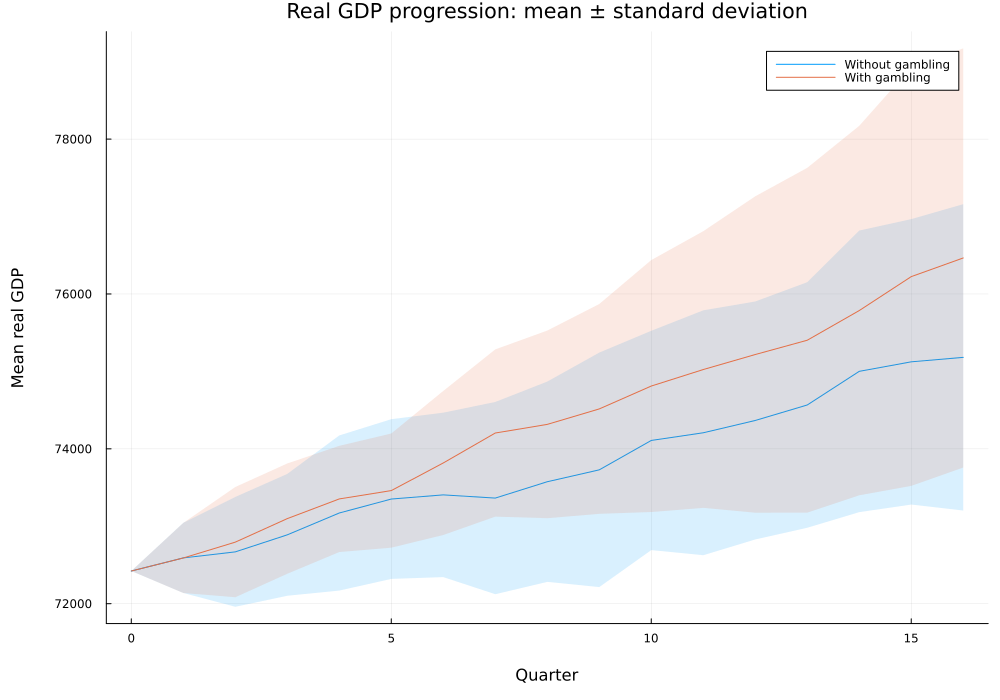

In [3]:
gdp_path = first(path for path in (
    joinpath(pwd(), "data", "paired-gdp-paths.csv"),
    joinpath(pwd(), "dba-studies", "gambling-market", "data", "paired-gdp-paths.csv"),
) if isfile(path))

gdp_paths = CSV.read(gdp_path, DataFrame)
@assert nrow(gdp_paths) == 20 * 2 * 17

gdp_progression = combine(
    groupby(gdp_paths, [:scenario, :period]),
    :real_gdp => mean => :mean_real_gdp,
    :real_gdp => std => :std_real_gdp,
)
sort!(gdp_progression, [:scenario, :period])

baseline_gdp = filter(:scenario => ==("baseline"), gdp_progression)
gambling_gdp = filter(:scenario => ==("gambling"), gdp_progression)

plot(
    baseline_gdp.period,
    baseline_gdp.mean_real_gdp;
    ribbon = baseline_gdp.std_real_gdp,
    fillalpha = 0.15,
    label = "Without gambling",
    xlabel = "\nQuarter",
    ylabel = "Mean real GDP\n",
    title = "Real GDP progression: mean ± standard deviation",
    bottom_margin = 5Plots.mm,
    left_margin = 5Plots.mm,
    size = (1000,700)
)

plot!(
    gambling_gdp.period,
    gambling_gdp.mean_real_gdp;
    ribbon = gambling_gdp.std_real_gdp,
    fillalpha = 0.15,
    label = "With gambling",
)

Para verificarmos isto de maneira mais precisa, vamos analisar os intervalos de confiança estatísticos de cada cenário de simulação e entender se há relevância estatística. 

Abaixo temos uma tabela que compila o teste estatístico para as variáveis: 
- PIB ao final do período.
- Depósito das famílias. 
- Depósitos dos empresários. 
- Consumo agregado. 

Podemos verificar, usando a distribuição Student t para aproximar a distribuição das médias, que nenhuma das variáveis tem impacto com significância estatística com intervalo de confiança de 95%.  


In [4]:
results_path = first(path for path in (
    joinpath(pwd(), "data", "paired-results.csv"),
    joinpath(pwd(), "dba-studies", "gambling-market", "data", "paired-results.csv"),
) if isfile(path))

results = CSV.read(results_path, DataFrame)

tested_outcomes = [
    :final_real_gdp,
    :final_active_worker_deposits,
    :final_inactive_worker_deposits,
    :final_owner_deposits,
    :cumulative_household_consumption,
]

baseline = sort(filter(:scenario => ==("baseline"), results), :run)
gambling = sort(filter(:scenario => ==("gambling"), results), :run)

@assert baseline.run == gambling.run
@assert baseline.simulation_seed == gambling.simulation_seed

alpha = 0.05
number_of_tests = length(tested_outcomes)

significance = DataFrame(
    outcome = String[],
    mean_difference = Float64[],
    standard_error = Float64[],
    t_statistic = Float64[],
    degrees_of_freedom = Int[],
    p_value = Float64[],
    ci95_lower = Float64[],
    ci95_upper = Float64[],
)

for outcome in tested_outcomes
    differences = gambling[!, outcome] - baseline[!, outcome]

    n = length(differences)
    mean_difference = mean(differences)
    standard_error = std(differences) / sqrt(n)
    degrees_of_freedom = n - 1

    if iszero(standard_error)
        t_statistic = iszero(mean_difference) ? 0.0 : sign(mean_difference) * Inf
        p_value = iszero(mean_difference) ? 1.0 : 0.0
        margin = 0.0
    else
        distribution = TDist(degrees_of_freedom)
        t_statistic = mean_difference / standard_error
        p_value = 2 * ccdf(distribution, abs(t_statistic))
        critical_value = quantile(distribution, 1 - alpha / 2)
        margin = critical_value * standard_error
    end

    push!(
        significance,
        (
            string(outcome),
            mean_difference,
            standard_error,
            t_statistic,
            degrees_of_freedom,
            p_value,
            mean_difference - margin,
            mean_difference + margin,
        ),
    )
end

display(significance)

Row,outcome,mean_difference,standard_error,t_statistic,degrees_of_freedom,p_value,ci95_lower,ci95_upper
,String,Float64,Float64,Float64,Int64,Float64,Float64,Float64
1,final_real_gdp,1283.77,626.303,2.04976,19,0.0544479,-27.0958,2594.64
2,final_active_worker_deposits,360.003,509.248,0.70693,19,0.48819,-705.866,1425.87
3,final_inactive_worker_deposits,196.432,269.199,0.72969,19,0.47448,-367.009,759.873
4,final_owner_deposits,262.782,217.767,1.20671,19,0.242353,-193.01,718.575
5,cumulative_household_consumption,682.53,3429.92,0.198993,19,0.844382,-6496.38,7861.44


Além disso, podemos verificar o comportamento do indice de Gini para esse conjunto de simulações. 

Ao fazer isto, verificamos que há um impacto positivo na média, ou seja, que as simulações com transferências ativas teriam uma desigualdade maior. 

No entanto, considerando os desvios padrões, não há uma tendência clara ao longo do conjunto das simulações. 

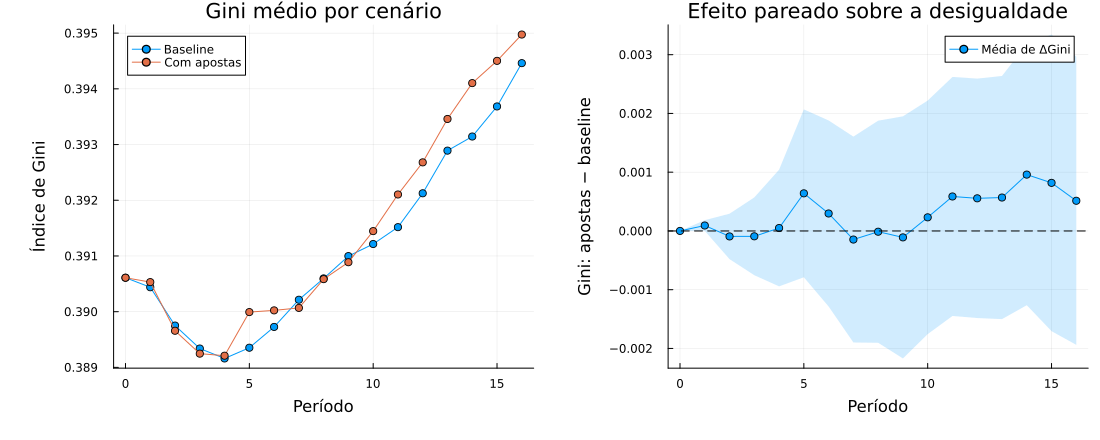

In [8]:
# Localiza o CSV a partir da pasta do notebook ou da raiz do projeto.
study_dir = isfile(joinpath(pwd(), "data", "paired-period-trace.csv")) ?
    pwd() :
    joinpath(pwd(), "dba-studies", "gambling-market")

trace_path = joinpath(study_dir, "data", "paired-period-trace.csv")
@assert isfile(trace_path) "Arquivo não encontrado: $trace_path"

# Carrega os resultados.
trace = CSV.read(trace_path, DataFrame)

pair_keys = [:run, :simulation_seed, :period]

baseline_trace = filter(:scenario => ==("baseline"), trace)
gambling_trace = filter(:scenario => ==("gambling"), trace)

sort!(baseline_trace, pair_keys)
sort!(gambling_trace, pair_keys)

# Confirma que base e tratamento estão corretamente pareados.
@assert nrow(baseline_trace) == nrow(gambling_trace)
@assert select(baseline_trace, pair_keys) ==
        select(gambling_trace, pair_keys)

# Monta apenas as variáveis necessárias para analisar o Gini.
paired = select(
    baseline_trace,
    pair_keys,
    :household_income_gini => :baseline_household_income_gini,
)

paired.gambling_household_income_gini =
    gambling_trace.household_income_gini

paired.delta_household_income_gini =
    paired.gambling_household_income_gini .-
    paired.baseline_household_income_gini

# Valor crítico da distribuição t de Student.
number_of_runs = length(unique(paired.run))
t_critical = quantile(TDist(number_of_runs - 1), 0.975)

# Calcula médias, erro-padrão e IC95% por período.
gini_by_period = combine(
    groupby(paired, :period),
    :baseline_household_income_gini => mean => :baseline,
    :gambling_household_income_gini => mean => :gambling,
    :delta_household_income_gini => mean => :delta_media,
    :delta_household_income_gini =>
        (x -> std(x) / sqrt(length(x))) => :erro_padrao,
)

sort!(gini_by_period, :period)

gini_by_period.ic95_inferior =
    gini_by_period.delta_media .-
    t_critical .* gini_by_period.erro_padrao

gini_by_period.ic95_superior =
    gini_by_period.delta_media .+
    t_critical .* gini_by_period.erro_padrao

# No período zero os cenários devem ser idênticos.
period_zero = only(
    filter(:period => ==(0), gini_by_period).delta_media,
)

@assert isapprox(period_zero, 0.0; atol = 1.0e-12)

# Gráfico dos níveis médios do Gini.
p_gini_levels = plot(
    gini_by_period.period,
    gini_by_period.baseline;
    marker = :circle,
    label = "Baseline",
    xlabel = "Período",
    ylabel = "Índice de Gini",
    title = "Gini médio por cenário",
)

plot!(
    p_gini_levels,
    gini_by_period.period,
    gini_by_period.gambling;
    marker = :circle,
    label = "Com apostas",
)

# Gráfico do efeito pareado com IC95%.
p_gini_delta = plot(
    gini_by_period.period,
    gini_by_period.delta_media;
    ribbon = (
        gini_by_period.delta_media .-
        gini_by_period.ic95_inferior,
        gini_by_period.ic95_superior .-
        gini_by_period.delta_media,
    ),
    fillalpha = 0.18,
    marker = :circle,
    label = "Média de ΔGini",
    xlabel = "Período",
    ylabel = "Gini: apostas − baseline",
    title = "Efeito pareado sobre a desigualdade",
)

hline!(
    p_gini_delta,
    [0.0];
    color = :black,
    linestyle = :dash,
    linewidth = 1,
    label = false,
)

# Exibe os dois gráficos lado a lado.
plot(
    p_gini_levels,
    p_gini_delta;
    layout = (1, 2),
    size = (1100, 440),
    left_margin = 12 * Plots.mm,
    bottom_margin = 10 * Plots.mm,
)

Este resultado nos provoca a realizar mais simulações com variações na quantidade de recursos transferidos e na  participação da população que aposta. Ao fazer isto, podemos verificar se há uma relação entre PIB e renda transferida nas apostas. 

Para isto, rodamos as seguintes configurações combinadas:

- Percentuais de apostas: 2%, 5%, 10% e 20%
- Percentuais de famílias apostadoras: 10%, 20%, 40% e 60%

Essas configurações resultaram em 340 simulações (1 baseline e 16 tratamentos) que nos permitem comparar diferentes cenários do PIB para cada uma delas. 

Os resultados dessas simulações são carregados na célula que segue.

In [ ]:
study_dir = isfile(joinpath(pwd(), "data", "gambling-grid-period-trace.csv")) ?
    pwd() : joinpath(pwd(), "dba-studies", "gambling-market")
trace_path = joinpath(study_dir, "data", "gambling-grid-period-trace.csv")
results_path = joinpath(study_dir, "data", "gambling-grid-results.csv")
summary_path = joinpath(study_dir, "data", "gambling-grid-cell-summary.csv")
@assert all(isfile, [trace_path, results_path, summary_path])

grid_trace = CSV.read(trace_path, DataFrame)
grid_results = CSV.read(results_path, DataFrame)
grid_summary = CSV.read(summary_path, DataFrame)
sort!(grid_trace, [:run, :scenario_id, :period])

(simulacoes = nrow(grid_results), trajetorias = nrow(grid_trace), celulas = 16)

(simulacoes = 340, trajetorias = 5780, celulas = 16)

O gráfico abaixo reúne os boxplots da diferença do PIB final entre cada cenário e o cenário baseline. Ou seja, para cada rodada temos: 

$$
\Delta PIB^{final}_r
=
PIB^{tratamento}_{r,16}
-
PIB^{base}_{r,16}
$$


Assim, o box plot representa a distribuição do impacto no PIB final versus o baseline de cada uma das combinações possíveis.

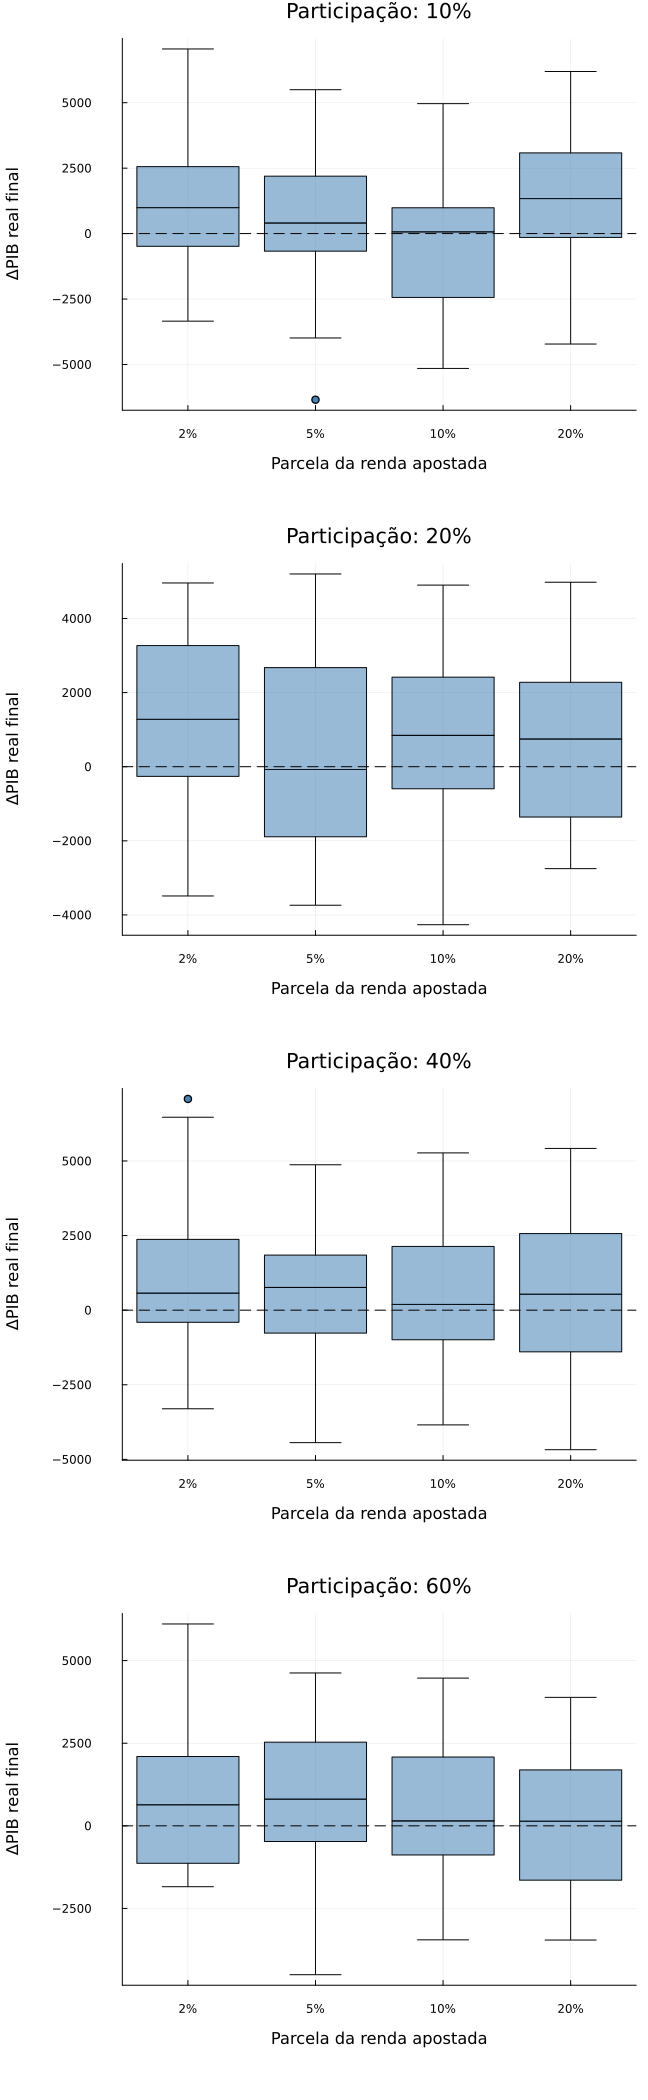

In [ ]:
outcome_columns = [
    :real_gdp, :household_income_gini,
    :real_household_consumption, :real_government_consumption,
    :real_capitalformation, :real_exports, :real_imports,
    :household_domestic_purchase_expenditure,
    :household_imported_purchase_expenditure,
    :household_unfilled_purchase_demand,
    :firm_sales, :firm_profit, :firm_output_realized,
    :firm_employment_realized, :firm_investment_realized,
]

baseline_trace = filter(:scenario_id => ==("baseline"), grid_trace)
treatment_trace = filter(:scenario_id => !=("baseline"), grid_trace)
baseline_lookup = Dict(
    (row.run, row.simulation_seed, row.period) => row
    for row in eachrow(baseline_trace)
)
paired = copy(treatment_trace)
for outcome in outcome_columns
    delta = Symbol("delta_", String(outcome))
    paired[!, delta] = [
        getproperty(row, outcome) - getproperty(
            baseline_lookup[(row.run, row.simulation_seed, row.period)],
            outcome,
        )
        for row in eachrow(treatment_trace)
    ]
end

gambling_shares = sort(unique(
    grid_results.gambling_income_share[grid_results.gambling_income_share .> 0]
))
participation_shares = sort(unique(
    grid_results.worker_participation_share
))
share_position = Dict(
    share => index for (index, share) in enumerate(gambling_shares)
)
share_labels = [
    "$(round(Int, 100 * share))%" for share in gambling_shares
]
final_effects = paired[paired.period .== maximum(paired.period), :]

p_gdp_boxes = map(participation_shares) do participation
    cell = final_effects[
        final_effects.worker_participation_share .== participation,
        :,
    ]
    x = [share_position[share] for share in cell.gambling_income_share]
    p = boxplot(
        x, cell.delta_real_gdp;
        xticks = (eachindex(gambling_shares), share_labels),
        xlabel = "Parcela da renda apostada",
        ylabel = "ΔPIB real final",
        title = "Participação: $(round(Int, 100 * participation))%",
        color = :steelblue, fillalpha = 0.55,
        outliers = true, legend = false,
    )
    hline!(p, [0.0]; color = :black, linestyle = :dash, label = false)
    p
end

plot(
    p_gdp_boxes...;
    layout = (length(participation_shares), 1), link = :y,
    size = (650, 2100),
    left_margin = 18 * Plots.mm, bottom_margin = 12 * Plots.mm,
)

Após a visualização, podemos verificar a significância estatística assim como fizemos com a simulação inicial. 

Na tabela que segue, verificamos que em todos os casos o intervalo de confiança contém o zero, assim não conseguimos aferir que há um efeito significativo do aumento de volume e cobertura das transferências no PIB final da simulação. 

In [ ]:
final_gdp_summary = filter(:metric => ==("final_real_gdp"), grid_summary)
final_gdp_table = DataFrame(
    Participação = [
        "$(round(Int, 100 * participation))%"
        for participation in participation_shares
    ],
)

for gambling_share in gambling_shares
    column = Symbol("$(round(Int, 100 * gambling_share))%")
    final_gdp_table[!, column] = [
        let row = only(eachrow(final_gdp_summary[
            (final_gdp_summary.gambling_income_share .== gambling_share) .&
            (final_gdp_summary.worker_participation_share .== participation),
            :,
        ]))
            @sprintf("%+.1f [%+.1f; %+.1f]", row.mean_delta, row.ci_lower, row.ci_upper)
        end
        for participation in participation_shares
    ]
end

display(final_gdp_table)

Row,Participação,2%,5%,10%,20%
,String,String,String,String,String
1,10%,+1283.8 [-27.1; +2594.6],+538.6 [-759.4; +1836.6],-408.2 [-1652.2; +835.9],+1175.9 [-83.4; +2435.1]
2,20%,+1120.2 [-135.0; +2375.5],+335.2 [-1023.8; +1694.2],+852.2 [-247.9; +1952.3],+616.2 [-472.1; +1704.5]
3,40%,+1089.6 [-230.2; +2409.3],+442.5 [-554.7; +1439.7],+637.6 [-497.3; +1772.5],+443.3 [-950.2; +1836.9]
4,60%,+812.0 [-167.6; +1791.5],+583.1 [-650.5; +1816.7],+667.5 [-407.2; +1742.2],+78.8 [-922.6; +1080.2]


Assim, verificamos que não é possível estabelecer uma relação entre as transferências dos mercados de apostas e o nível do PIB das simulações. 